In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Open the spreadsheet

In [2]:
# 1. Define the file path and sheet name
file_path = 'graph_ingredients.xlsx'
sheet = 'Edge List_Expanded'

# 2. Load data into a DataFrame

In [3]:
# 2. Read the Excel file into a DataFrame
df = pd.read_excel(file_path, sheet_name=sheet)

# 3. View the first few rows to confirm it worked
print(df.head())

df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce').fillna(0)

    Source                 Target  Weight  \
0     Root                Younger     0.4   
1     Root               Same age     0.4   
2     Root                  Older     0.2   
3  Younger  Younger (child's gen)     0.5   
4  Younger     Younger (same gen)     0.5   

                                             Note  \
0  Branch probability = 0.4 (Estimated frequency)   
1  Branch probability = 0.4 (Estimated frequency)   
2  Branch probability = 0.2 (Estimated frequency)   
3         Branch probability = 0.5 (Evenly split)   
4         Branch probability = 0.5 (Evenly split)   

                          Cumulative Logic  
0                   1.0 (Root) * 0.4 = 0.4  
1                   1.0 (Root) * 0.4 = 0.4  
2                   1.0 (Root) * 0.2 = 0.2  
3  0.4 (Incoming from Younger) * 0.5 = 0.2  
4  0.4 (Incoming from Younger) * 0.5 = 0.2  


# 3. Create the Graph

In [4]:
# 3. Create the Graph
G = nx.from_pandas_edgelist(df, source='Source', target='Target', edge_attr='Weight')

# 4. Visualize

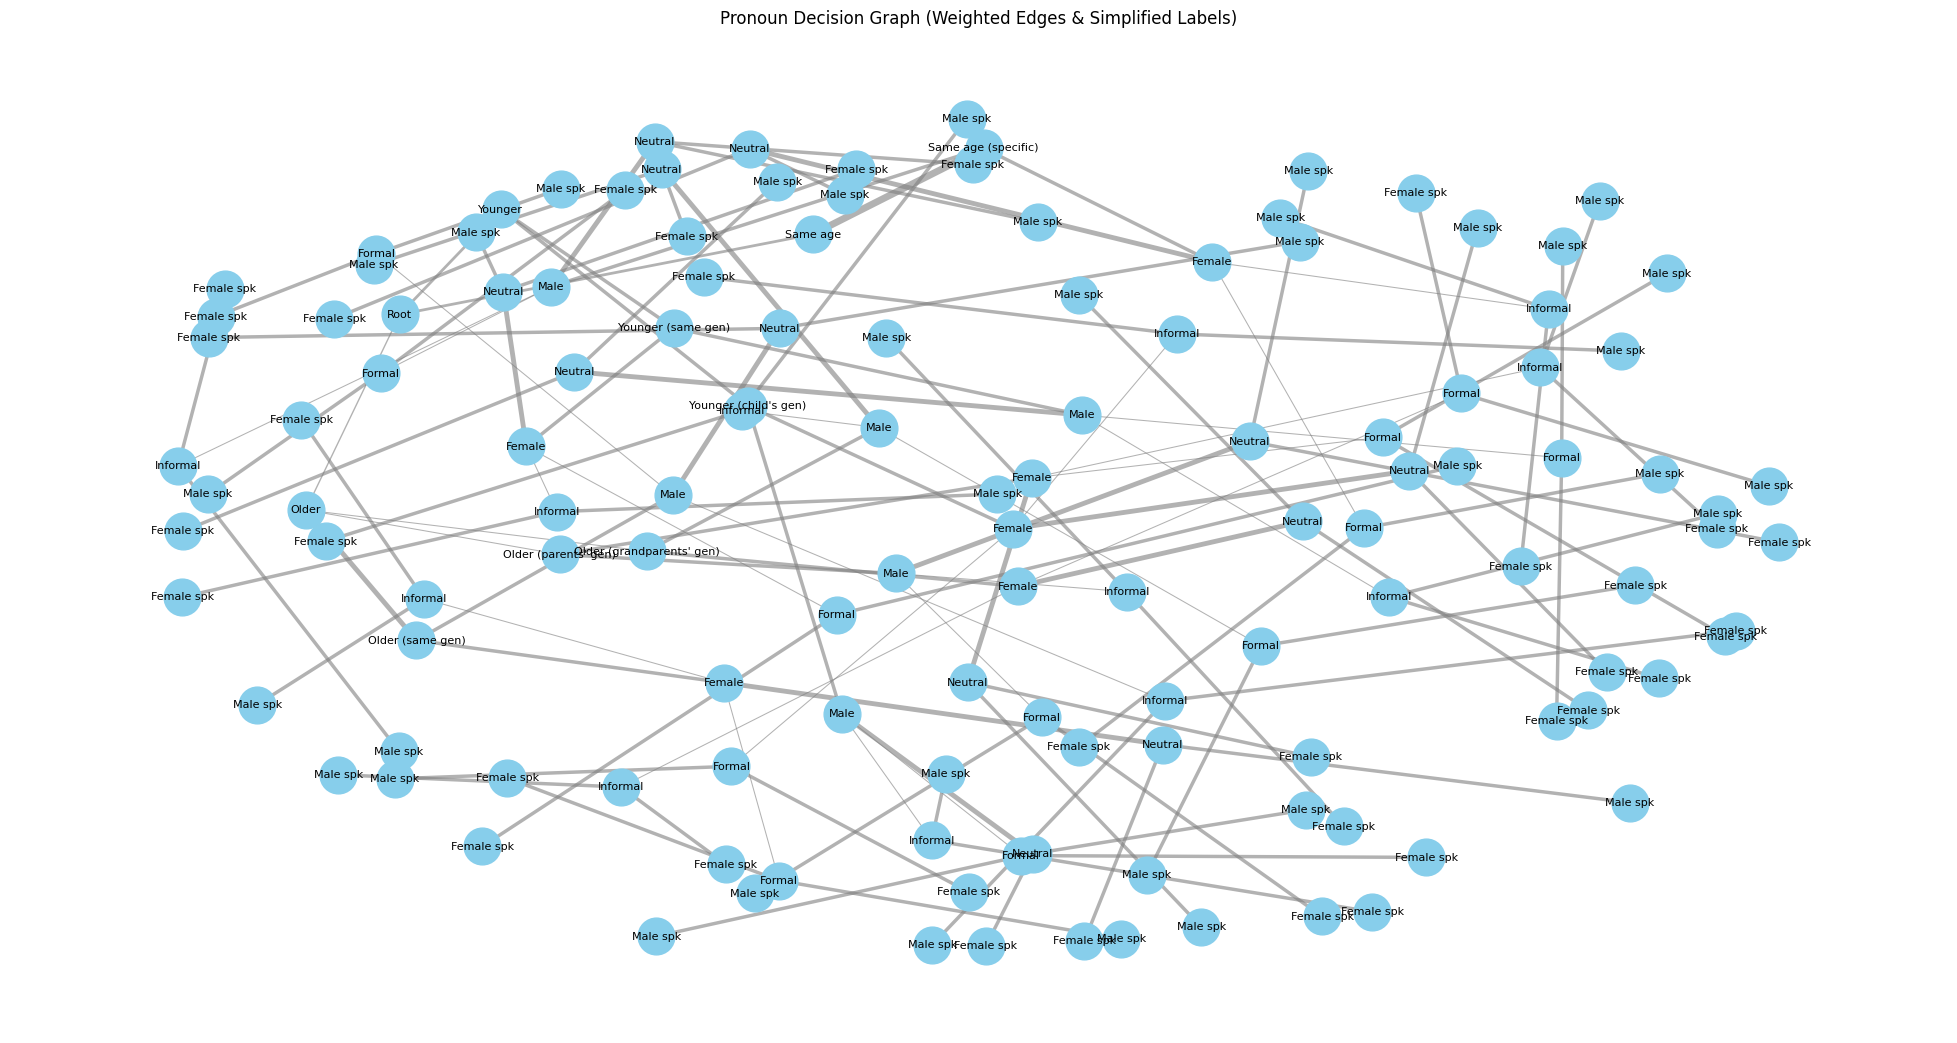

In [5]:
plt.figure(figsize=(25, 13)) # Increased height slightly for better spacing
pos = nx.spring_layout(G, k=0.5) # Layout for nodes

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')

# Draw edges with thickness based on Weight
weights = [G[u][v]['Weight'] * 5 for u, v in G.edges()] # Scaling weight for visibility
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)

# --- MODIFICATION: Create simplified labels ---
# This splits the string by " - " and takes the very last element
# Example: "Younger - Male - Neutral" becomes just "Neutral"
short_labels = {node: str(node).split(' - ')[-1] for node in G.nodes()}

# Draw labels using the new 'labels' parameter
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_family='sans-serif')

plt.title("Pronoun Decision Graph (Weighted Edges & Simplified Labels)")
plt.axis('off')
plt.show()

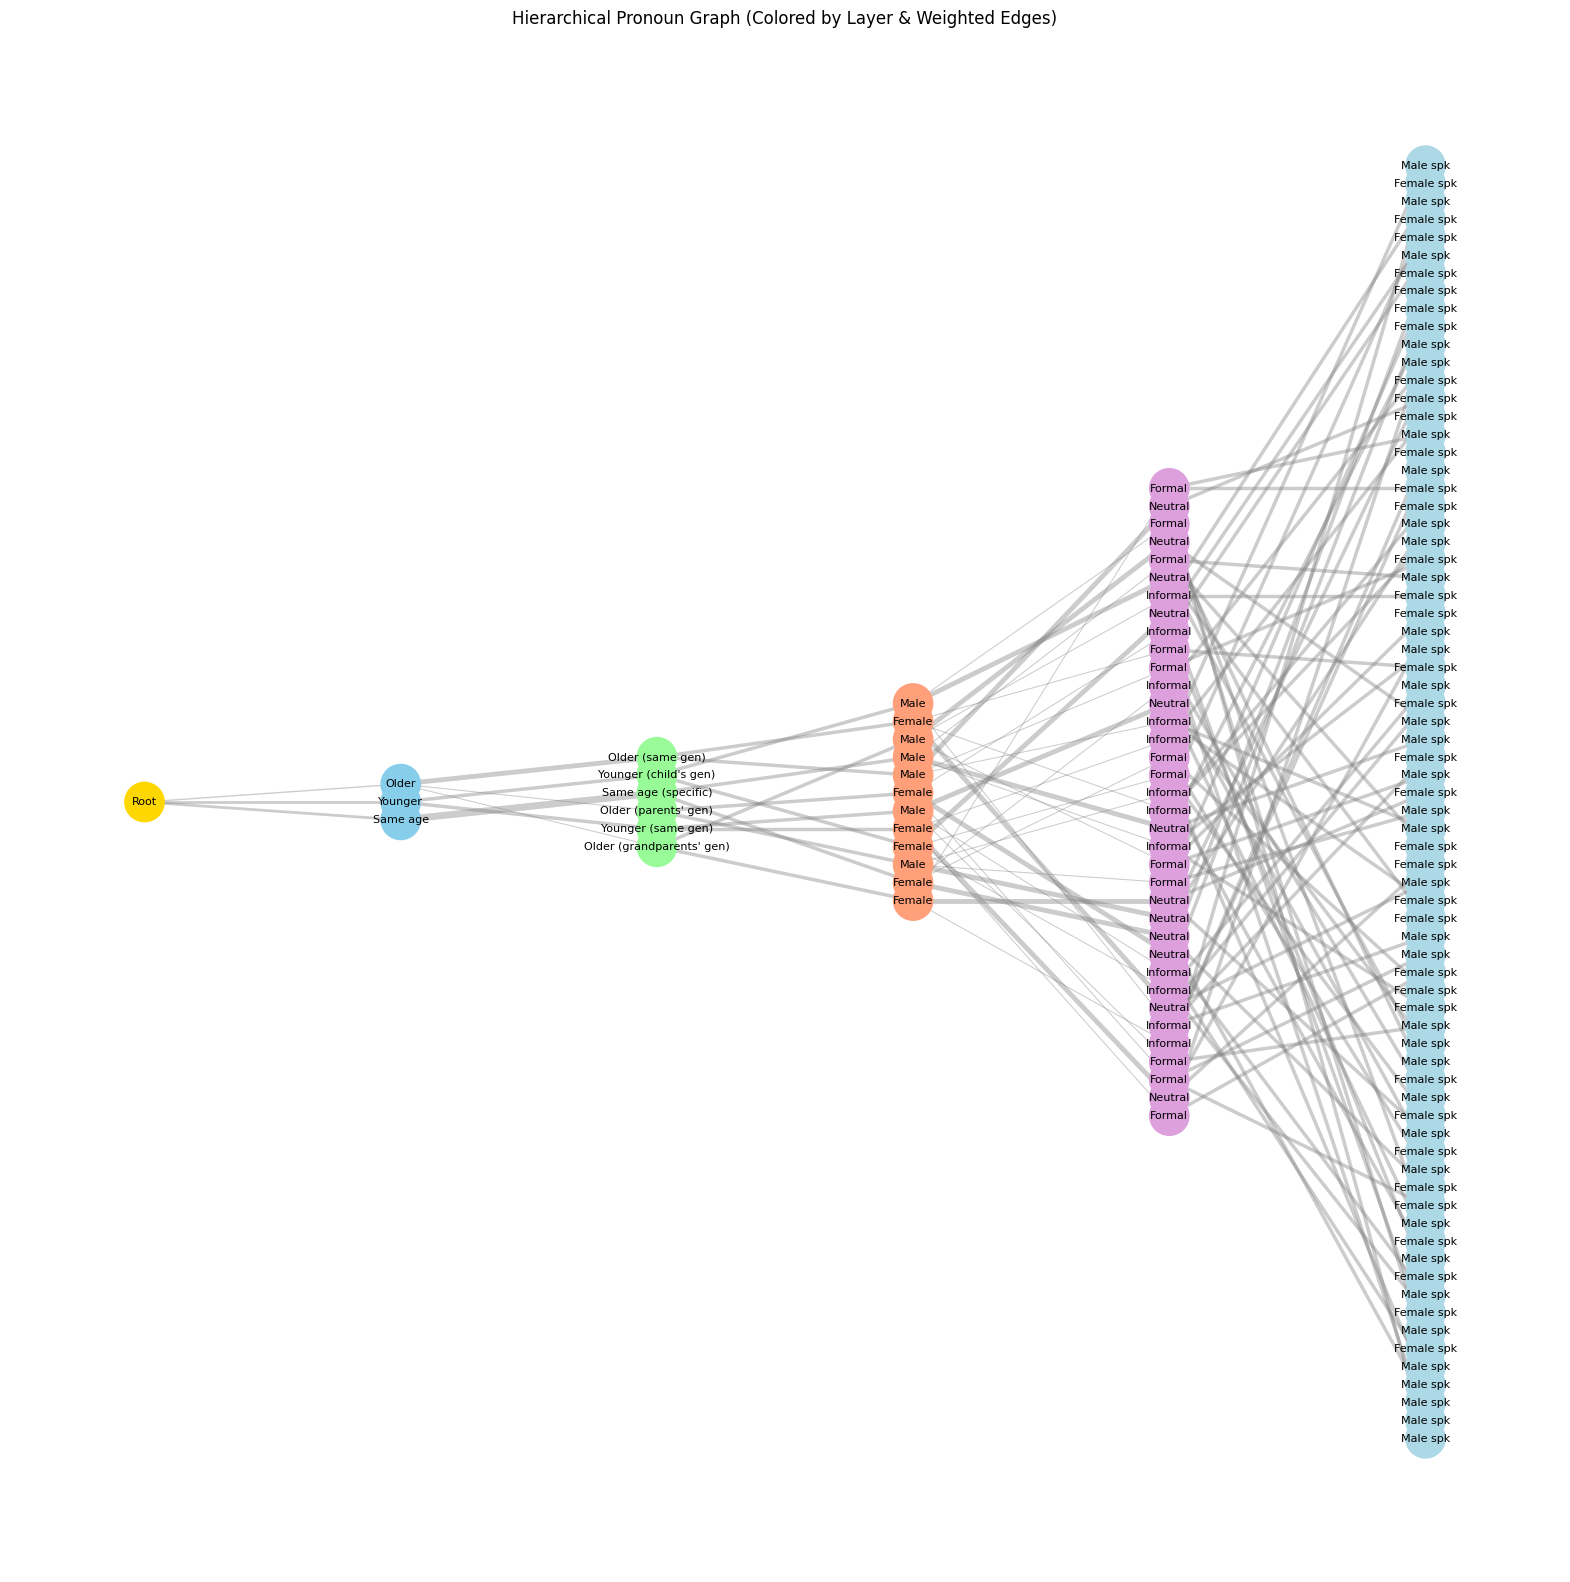

In [6]:
# 1. Calculate depth from Root to determine layers (if not already done)
depths = nx.single_source_shortest_path_length(G, 'Root')
for node, depth in depths.items():
    G.nodes[node]['layer'] = depth

# 2. Define your color palette for each layer
# Layer 0: Root, Layer 1: Age, Layer 2: Gender, Layer 3: Social, Layer 4: Speaker
layer_colors = {
    0: '#FFD700', # Gold
    1: '#87CEEB', # Sky Blue
    2: '#98FB98', # Pale Green
    3: '#FFA07A', # Light Salmon
    4: '#DDA0DD', # Plum
    5: '#ADD8E6'  # Light Blue - Added for layer 5
}

# 3. Create a list of colors for each node in the order they appear in G.nodes()
node_colors = [layer_colors[G.nodes[n]['layer']] for n in G.nodes()]

# 4. Visualize
plt.figure(figsize=(20, 20))
# Use multipartite_layout for the hierarchical look
pos = nx.multipartite_layout(G, subset_key='layer')

# Draw nodes with the new node_colors list
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors)

# Draw edges with thickness based on Weight
weights = [G.get_edge_data(u, v, default={}).get('Weight', 0) * 5 for u, v in G.edges()] # Added .get('Weight', 0) to handle missing 'Weight' attribute
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.4)

# Create simplified labels
short_labels = {node: str(node).split(' - ')[-1] for node in G.nodes()}

# Draw labels
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_family='sans-serif')

plt.title("Hierarchical Pronoun Graph (Colored by Layer & Weighted Edges)")
plt.axis('off')
plt.show()

## ⭐ **WE CAN MODIFY THE WEIGHTS or YOU GUYS CAN ADD YOUR FEEDBACKS/IDEAS HERE**

* Age: Most of people in the target group know how to address pronouns to the older, but face difficulties with youngers and same age.
  * Root - Younger: 0.4
  * Root - Same age: 0.4
  * Root - Older: 0.2
* Age (specific):
  * Younger group:
    * younger - Younger (child's gen): 0.5
    * Younger - Younger (same gen): 0.5
  * Same age group
    * Same age- Same age: 1
  * Older group: Target group mostly talks vietnamese to people who are around parents' or grandparents' gen
    * Older - Older (same gen): 0.7
    * Older - Older (parents' gen): 0.15
    * Older - Older (grandparents' gen): 0.15
* Gender:
  * ~ - Male: 0.5
  * ~ - Female: 0.5
* Social: The game is now designed for social situations. In my opinion, the case neutral can be the most frequent that learners can face, when they talk to others in real life. But we can modify the weight for this layer. At the moment, I set it as:
  * ~ - Informal: 0.15
  * ~ - Neutral: 0.7
  * ~ - Formal: 0.15
* Speaker gender:
  * ~ - Male: 0.5
  * ~ - Female: 0.5

# 5. Weights → Edges for similarity
Similarity here indicates more frequent scenerios

In [7]:
import itertools

# 1. Identify nodes (layer 5)
"""Extracts Nodes: It finds all the end scenarios (nodes at layer 5)."""

leaf_nodes = [n for n, attr in G.nodes(data=True) if attr.get('layer') == 5]


# 2. Extract features for each node by tracing the shortest path from Root
"""Extracts Features:
    It traces the path back to the root for each node to figure out its specific attributes
    (Age, Age specific, Gender, Social, Speaker Gender)."""

leaf_features = {}
for leaf in leaf_nodes:
    path = nx.shortest_path(G, source='Root', target=leaf)
    # The path contains nodes at each layer:
    # [Root, Age, Age(specific), Gender, Social, Speaker Gender]
    age = path[1]
    age_spec = path[2]
    # Extract just the specific attribute name from the long node label
    gender = path[3].split(' - ')[-1]
    social = path[4].split(' - ')[-1]
    spk_gender = path[5].split(' - ')[-1]

    leaf_features[leaf] = [age, age_spec, gender, social, spk_gender]


# 3. Define the weights for each feature value based on our requirements
weight_dict = {
    'Younger': 0.4, 'Same age': 0.4, 'Older': 0.2,
    "Younger (child's gen)": 0.5, 'Younger (same gen)': 0.5,
    'Same age (specific)': 1.0,  # Updated to match the restored label
    'Older (same gen)': 0.7, "Older (parents' gen)": 0.15, "Older (grandparents' gen)": 0.15,
    'Male': 0.5, 'Female': 0.5,
    'Informal': 0.15, 'Neutral': 0.7, 'Formal': 0.15,
    'Male spk': 0.5, 'Female spk': 0.5
}


# 4. Calculate similarity scores between all pairs of nodes
"""Calculates Similarity:
    It compares every pair of nodes.
    If they share an attribute, it adds the weight of that attribute to their similarity score."""

similarity_edges = []
for u, v in itertools.combinations(leaf_nodes, 2):
    feat_u = leaf_features[u]
    feat_v = leaf_features[v]

    sim_score = 0
    for f1, f2 in zip(feat_u, feat_v):
        if f1 == f2:
            # Add the weight if they share the same feature. Default to 0.1 if not found just in case.
            sim_score += weight_dict.get(f1, 0.1)

    # Only add an edge if the similarity is reasonably high
    # The max possible score is 0.4 + 1.0 + 0.5 + 0.7 + 0.5 = 3.1 (Eg: Same age - Same age - Female - Neutral - Female Spk)
    if sim_score >= 1.8:
      # set it to 1.8 to avoid a completely cluttered graph, but we can adjust this
        similarity_edges.append((u, v, sim_score))


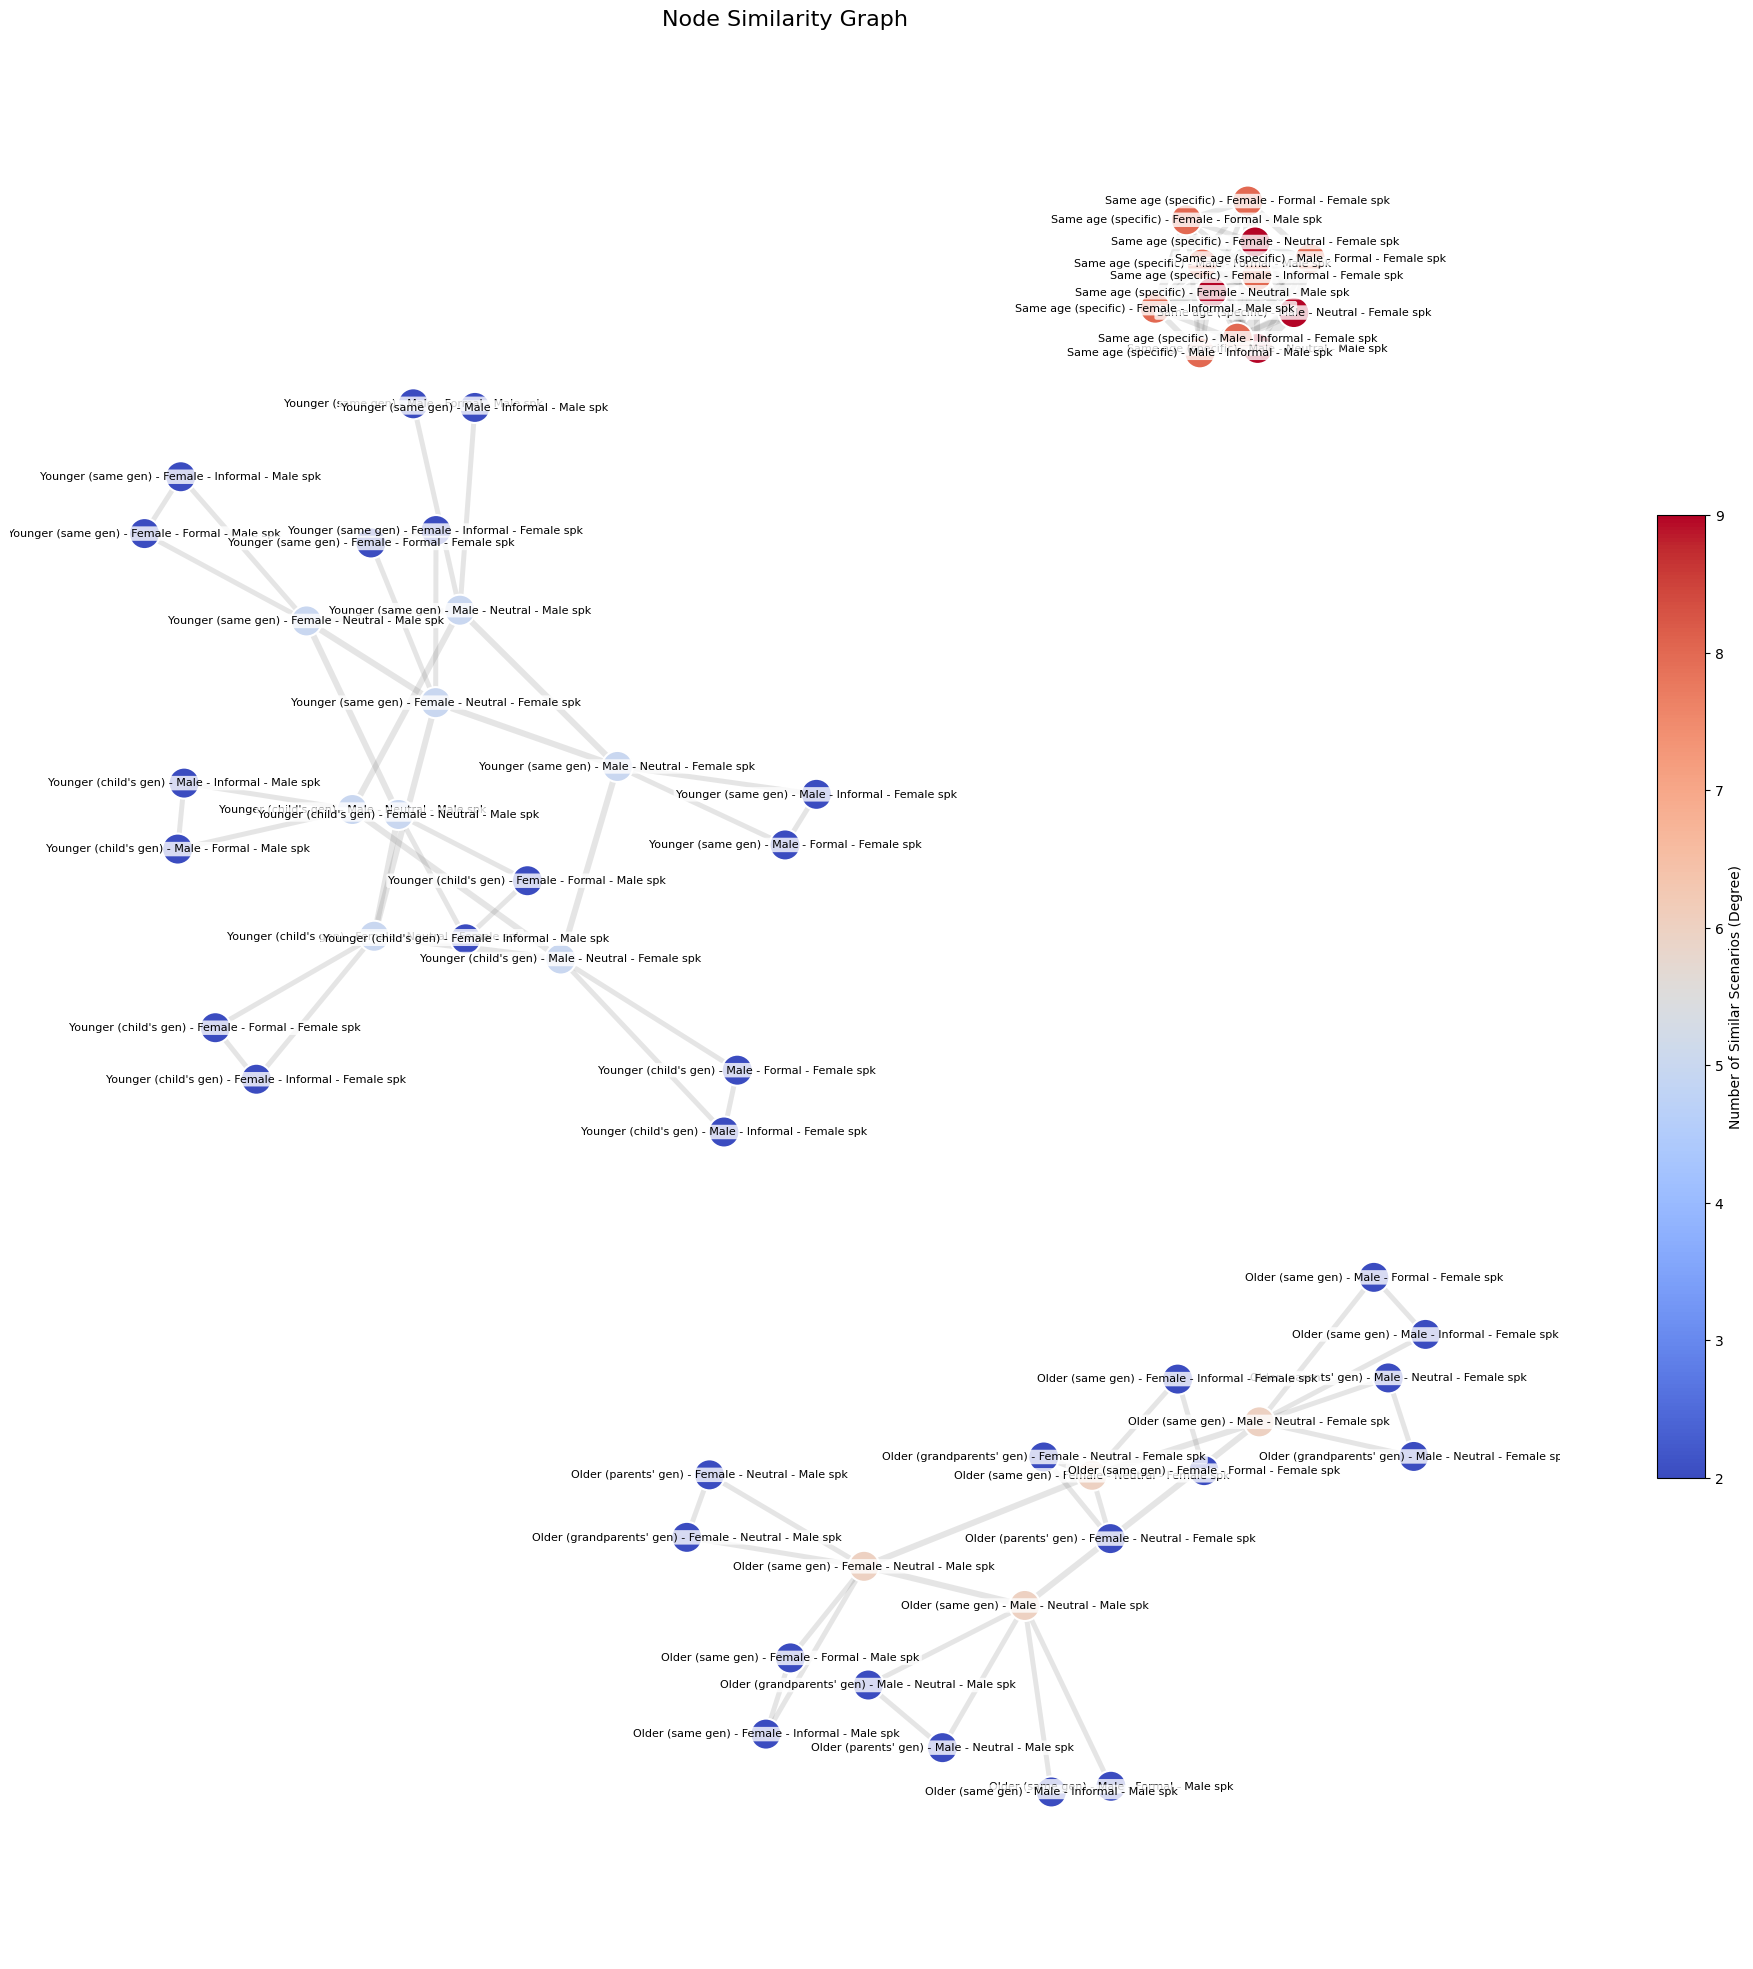

In [8]:
# 5. Create and Visualize the Similarity Graph
"""Visualizes:
    It plots a new graph where edges only exist if the similarity score is above a certain threshold
    (At the moment, set it to 1.8 to avoid a completely cluttered graph, but we can adjust this).
    Thicker edges mean higher similarity."""

S = nx.Graph()
for u, v, w in similarity_edges:
    S.add_edge(u, v, weight=w)

# Adjusted 'k' for better spacing between clusters, and increased iterations for stability
pos_s = nx.spring_layout(S, k=0.3, iterations=50, seed=42)

# Calculate node degree to use for coloring (more connected = hotter color)
degrees = dict(S.degree())
node_colors = [degrees[n] for n in S.nodes()]

# Define edge_weights based on the similarity scores
edge_weights = [S[u][v]['weight'] ** 2 for u, v in S.edges()]

# 5 = Shows the full path (e.g., "Younger (child's gen) - Male - Informal - Female spk")
parts_to_show = 5

# Create the custom labels based on your choice above
custom_labels = {n: " - ".join(str(n).split(' - ')[-parts_to_show:]) for n in S.nodes()}

# --- Drawing the Graph ---
plt.figure(figsize=(25, 25))

# Re-draw Nodes
nodes = nx.draw_networkx_nodes(S, pos_s, node_size=500, node_color=node_colors,
                               cmap=plt.cm.coolwarm, edgecolors='white', linewidths=1.5)

# Re-draw Edges
nx.draw_networkx_edges(S, pos_s, width=edge_weights, alpha=0.15, edge_color='#555555')

# Draw the Custom Labels
nx.draw_networkx_labels(S, pos_s, labels=custom_labels, font_size=8, font_family='sans-serif',
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title(f"Node Similarity Graph", fontsize=16)
plt.axis('off')
plt.colorbar(nodes, label="Number of Similar Scenarios (Degree)", shrink=0.5, aspect=20)
plt.show()

# DRAFT: PLUG-IN DATA

## 1. Finalize the Graph (The 4-Layer Flattening)

We need to update your graph generation code to drop the "child's generation" (since you have no data for it) and compress the graph into your exact 4-step flow: Age >> Addressee Gender >> Social Context >> Speaker Gender.

In [9]:
import pandas as pd
import networkx as nx
import uuid
import random

# 1. Initialize Graph and Load Data
G = nx.DiGraph()
db_df = pd.read_excel("db_pronouns_social-adressing_v1.xlsx", sheet_name="input_nodes")

# Filter out the 'child's gen' rows since we aren't using them in the game
db_df = db_df[~db_df['adressing relation'].str.contains("child")]

# 2. The 4-Layer Mapping Function
def map_game_nodes(row):
    relation = str(row['adressing relation']).lower()
    note = str(row['any note?']).lower()
    
    # Layer 1: Age (Simplified)
    if "younger" in relation: age = "Younger"
    elif "older" in relation or "uncle" in relation or "senior" in relation or "grandparent" in relation: age = "Older"
    else: age = "Same Age"
        
    # Layer 2: Addressee Gender
    addr_options = ["Male", "Female"]
    if "you as male" in note or "uncle" in relation or "brother" in note: addr_options = ["Male"]
    elif "you as female" in note or "aunt" in relation or "sister" in note: addr_options = ["Female"]

    # Layer 3: Social Context
    social_options = ["Neutral"]
    if "formal" in note: social_options = ["Formal"]
    elif "casual" in note or "informal" in note: social_options = ["Informal"]
        
    # Layer 4: Speaker Gender
    spk_options = ["Male spk", "Female spk"]
    if "male speaker" in note or "i/me as male" in note: spk_options = ["Male spk"]
    elif "female speaker" in note or "i/me as female" in note: spk_options = ["Female spk"]

    # Generate the 4-part paths
    paths = []
    for addr in addr_options:
        for social in social_options:
            for spk in spk_options:
                paths.append(f"{age} - {addr} - {social} - {spk}")
    return paths

# 3. Build the Graph
for index, row in db_df.iterrows():
    target_paths = map_game_nodes(row)
    instance_id = f"Instance_{uuid.uuid4().hex[:6]}"
    
    term_i = str(row['terms (i/me)']).strip() if pd.notna(row['terms (i/me)']) else ""
    term_you = str(row['terms (you)']).strip() if pd.notna(row['terms (you)']) else ""
    lang = row['language']
    
    # Add Instance Node
    G.add_node(instance_id, type="instance", language=lang, term_i=term_i, term_you=term_you)
    
    # Attach to Schema Paths
    for path in target_paths:
        # We ensure the schema node exists just by adding the edge
        G.add_edge(path, instance_id)

print(f"Graph Finalized! Inserted {len([n for n, attr in G.nodes(data=True) if attr.get('type') == 'instance'])} language instances.")

Graph Finalized! Inserted 59 language instances.


## 2. Create the "Data Extractor" for the Game

The game will hand the graph a "Path" and a "Language", and the graph will hand back the correct pronouns.

In [10]:
def get_answer_from_graph(graph, logic_path, language):
    """Searches the graph for the correct pronoun pair based on the path and language."""
    if logic_path not in graph:
        return None # Path doesn't exist in schema
    
    # Look at all instances connected to this logic path
    for neighbor in graph.neighbors(logic_path):
        node_data = graph.nodes[neighbor]
        if node_data.get('type') == 'instance' and node_data.get('language') == language:
            return {"I": node_data['term_i'], "You": node_data['term_you']}
            
    return None # No data for this specific language/path combo

## 3. Build the Game Flow (The Queue System)

This is the interactive part - Draft

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random

# --- 1. The Game Data (Using Similarity Logic for Hints) ---
# We define the correct path, and explicitly define the "similar" wrong paths 
# so we can give smart, targeted hints!
quiz_queue = [
    {
        "lang": "Vietnamese",
        "scenario": "You are a male university student talking to a male senior who is 2 years older.",
        "correct_path": "Older - Male - Neutral - Male spk",
        "wrong_options": [
            {"path": "Same age - Male - Neutral - Male spk", "hint": "Close! But this pronoun pair is for friends of the exact same age."},
            {"path": "Younger - Male - Neutral - Male spk", "hint": "Careful! This pair implies you are talking to someone younger than you."},
            {"path": "Older - Female - Neutral - Male spk", "hint": "Almost! But you changed the gender of the person you are talking to."}
        ]
    },
    {
        "lang": "Mandarin",
        "scenario": "You are buying fruit from a middle-aged female vendor at the local market.",
        "correct_path": "Older - Female - Neutral - Male spk", 
        "wrong_options": [
            {"path": "Same age - Female - Neutral - Male spk", "hint": "Close! But this implies she is your peer/same age, not middle-aged."},
            {"path": "Older - Male - Neutral - Male spk", "hint": "Wrong gender! That is the term for a middle-aged male (Uncle)."}
        ]
    }
]

# --- 2. The Game Engine & UI ---

out = widgets.Output()

def load_question():
    with out:
        clear_output()
        if len(quiz_queue) == 0:
            print("🎉 CONGRATULATIONS! You cleared the queue and mastered all the pronouns! 🎉")
            return

        current_q = quiz_queue[0]
        
        # Fetch actual pronouns from your graph G
        correct_data = get_answer_from_graph(G, current_q['correct_path'], current_q['lang'])
        if not correct_data:
            print(f"⚠️ Missing graph data for {current_q['lang']}! Skipping...")
            quiz_queue.pop(0)
            load_question()
            return
            
        print(f"🌍 Language: {current_q['lang']}  |  📝 Remaining: {len(quiz_queue)}")
        print(f"📖 Scenario: {current_q['scenario']}\n")
        
        # Build the clickable options
        choices = [{"text": f"I: {correct_data['I']} / You: {correct_data['You']}", "is_correct": True, "hint": ""}]
        
        for wrong in current_q['wrong_options']:
            wrong_data = get_answer_from_graph(G, wrong['path'], current_q['lang'])
            if wrong_data:
                choices.append({
                    "text": f"I: {wrong_data['I']} / You: {wrong_data['You']}", 
                    "is_correct": False, 
                    "hint": wrong['hint']
                })
                
        random.shuffle(choices) # Mix up the buttons!

        # Create buttons
        buttons = []
        for choice in choices:
            btn = widgets.Button(description=choice['text'], layout=widgets.Layout(width='300px', height='40px'))
            # Attach the data to the button so it knows if it's right or wrong
            btn.is_correct = choice['is_correct']
            btn.hint = choice['hint']
            btn.on_click(handle_click)
            buttons.append(btn)
            
        display(widgets.VBox(buttons))
        display(feedback_text)

# The text that shows right/wrong
feedback_text = widgets.HTML(value="")

def handle_click(b):
    if b.is_correct:
        feedback_text.value = f"<b style='color:green;'>✅ CORRECT! Great job. Loading next...</b>"
        quiz_queue.pop(0) # Remove from queue
        
        # Wait 1.5 seconds then load next
        import threading
        def next_q():
            import time
            time.sleep(1.5)
            feedback_text.value = ""
            load_question()
        threading.Thread(target=next_q).start()
        
    else:
        feedback_text.value = f"<b style='color:red;'>❌ INCORRECT.</b> <br><i>💡 Hint: {b.hint}</i><br>Moving to the back of the queue!"
        # Move to back of queue
        failed_q = quiz_queue.pop(0)
        quiz_queue.append(failed_q)
        
        import threading
        def next_q():
            import time
            time.sleep(3) # Give them time to read the hint!
            feedback_text.value = ""
            load_question()
        threading.Thread(target=next_q).start()

# Start the game
display(out)
load_question()

Output()

# Based on everything above, save graph + export graph

In [13]:
import pandas as pd
import networkx as nx
import uuid
import json
from networkx.readwrite import json_graph

G_schema = nx.DiGraph() 
db_df = pd.read_excel("db_pronouns_social-adressing_v1.xlsx", sheet_name="input_nodes")
db_df = db_df[~db_df['adressing relation'].str.contains("child", na=False)] 

def map_game_nodes(row):
    relation = str(row['adressing relation']).lower()
    note = str(row['any note?']).lower()
    
    # 🌟 FIX 1: Highly specific generation mapping!
    if "younger" in relation: 
        age = "Younger"
    elif "middle-age" in relation or "parents" in relation:
        age = "Middle-aged (parents' gen)"
    elif "senior" in relation or "grandparent" in relation:
        age = "Senior (grandparents' gen)"
    elif "older" in relation: 
        age = "Older (same gen)"
    else: 
        age = "Same Age"
        
    addr_options = ["Male", "Female"]
    if "you as male" in note or "bhai (male)" in note or "uncle" in relation or "uncle" in note: 
        addr_options = ["Male"]
    elif "you as female" in note or "baji/apa (female)" in note or "aunt" in relation or "aunty" in note or "khala" in note: 
        addr_options = ["Female"]

    social_options = ["Neutral"]
    if "formal" in note or "polite" in note or "respect" in note: 
        social_options = ["Formal"]
    elif "casual" in note or "informal" in note: 
        social_options = ["Informal"]
        
    spk_options = ["Male spk", "Female spk"]
    if "i/me as male" in note: 
        spk_options = ["Male spk"]
    elif "i/me as female" in note: 
        spk_options = ["Female spk"]

    paths = []
    for addr in addr_options:
        for social in social_options:
            for spk in spk_options:
                paths.append(f"{age} - {addr} - {social} - {spk}")
                
    return paths

# Build Schema
for index, row in db_df.iterrows():
    target_paths = map_game_nodes(row)
    for path in target_paths:
        G_schema.add_node(path, type="schema_path", layer=4)

# Plug Data
G_plugged = G_schema.copy()
for index, row in db_df.iterrows():
    target_paths = map_game_nodes(row)
    instance_id = f"Instance_{uuid.uuid4().hex[:6]}"
    
    term_i = str(row['terms (i/me)']).strip() if pd.notna(row['terms (i/me)']) else ""
    term_you = str(row['terms (you)']).strip() if pd.notna(row['terms (you)']) else ""
    lang = row['language']
    
    if term_i == "" and term_you == "": continue
        
    G_plugged.add_node(instance_id, type="instance", language=lang, term_i=term_i, term_you=term_you)
    for path in target_paths:
        G_plugged.add_edge(path, instance_id, type="HAS_PRONOUN")

# Export
plugged_data = json_graph.node_link_data(G_plugged)
with open("graph_export/graph_plugged_data.json", "w", encoding="utf-8") as f:
    json.dump(plugged_data, f, ensure_ascii=False, indent=4)
print("✅ Saved 'graph_plugged_data.json'")

✅ Saved 'graph_plugged_data.json'
